# 03 — Image Preprocessing & DataLoaders

Este notebook define el pipeline de preprocesamiento de imágenes y construye los `DataLoader`s de PyTorch
que consumirá el notebook de entrenamiento.

**El pipeline NO procesa imágenes a disco** — los transforms se aplican on-the-fly en tiempo de entrenamiento.

**Pipeline de transforms:**

| Paso | Train | Val / Test | Justificación |
|------|-------|------------|---------------|
| `CenterCrop(320)` | ✅ | ✅ | Galaxia siempre centrada; recorta estrellas periféricas |
| `Resize(224)` | ✅ | ✅ | Tamaño estándar EfficientNet-B0 / ResNet preentrenados |
| `RandomHorizontalFlip` | ✅ | ❌ | Galaxias simétricas; mueve estrellas del fondo |
| `RandomVerticalFlip` | ✅ | ❌ | Ídem |
| `RandomRotation(180°)` | ✅ | ❌ | Rotación 2D válida para las 6 clases morfológicas |
| `ColorJitter(b=0.15, c=0.15)` | ✅ | ❌ | Simula variaciones SDSS; conserva información de color físico |
| `ToTensor + Normalize(ImageNet)` | ✅ | ✅ | Obligatorio con pesos preentrenados |

**Output:** `train_loader`, `val_loader`, `test_loader` + `class_weights` listos para el notebook 04.

## Sección 1 — Imports y configuración

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

warnings.filterwarnings("ignore")

print(f"PyTorch version    : {torch.__version__}")
print(f"CUDA available     : {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device             : {device}")

PyTorch version    : 2.11.0+cu130
CUDA available     : False
Device             : cpu


In [ ]:
# Path configuration (Kaggle-compatible)
IS_KAGGLE = pathlib.Path("/kaggle/input").exists()

if IS_KAGGLE:
    _KAGGLE_CSV_SPLIT_ROOT    = pathlib.Path("/kaggle/input/datasets/jeancdevx/galaxy-morph-splits")
    _KAGGLE_IMAGES_ROOT = pathlib.Path("/kaggle/input/datasets/jaimetrickz/galaxy-zoo-2-images")
    IMAGES_DIR = _KAGGLE_IMAGES_ROOT / "images_gz2" / "images"
    SPLITS_DIR = _KAGGLE_CSV_SPLIT_ROOT
else:
    _LOCAL_ROOT = pathlib.Path("../data")
    IMAGES_DIR  = _LOCAL_ROOT / "images_gz2" / "images"
    SPLITS_DIR  = _LOCAL_ROOT / "splits"

# Hyperparameters
IMAGE_SIZE   = 224    # input size for EfficientNet-B0 / ResNet50
CROP_SIZE    = 320    # center crop before resize (removes peripheral stars)
BATCH_SIZE   = 32
# num_workers > 0 requires the Dataset class to be importable as a module (not __main__).
# Set to 0 for notebook execution; set to 4+ when running as a script or on Kaggle.
NUM_WORKERS  = 0
RANDOM_SEED  = 42

# ImageNet normalization stats (required for pretrained weights)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_ORDER = ["Elliptical", "Lenticular", "Spiral", "Barred_Spiral", "Edge_on", "Irregular"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_ORDER)}

print(f"Running on Kaggle : {IS_KAGGLE}")
print(f"Images directory  : {IMAGES_DIR}")
print(f"Splits directory  : {SPLITS_DIR}")
print(f"Image size        : {IMAGE_SIZE}×{IMAGE_SIZE} (crop from {CROP_SIZE}×{CROP_SIZE})")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Num workers       : {NUM_WORKERS}  (0 = main process, safe for notebooks)")
print(f"Class → index     : {CLASS_TO_IDX}")

Running on Kaggle : False
Images directory  : ../data/images_gz2/images
Splits directory  : ../data/splits
Image size        : 224×224 (crop from 320×320)
Batch size        : 32
Num workers       : 0  (0 = main process, safe for notebooks)
Class → index     : {'Elliptical': 0, 'Lenticular': 1, 'Spiral': 2, 'Barred_Spiral': 3, 'Edge_on': 4, 'Irregular': 5}


## Sección 2 — Definir transforms

In [3]:
# Train transforms: augmentation + normalization
train_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),           # keep galaxy center, trim peripheral stars
    transforms.Resize(IMAGE_SIZE),              # standard input size for pretrained models
    transforms.RandomHorizontalFlip(p=0.5),     # galaxies are symmetric; also displaces bg stars
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),     # 2D rotation valid for all 6 morphological classes
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.0,   # do NOT alter saturation: physical color info (redshift) must be preserved
        hue=0.0,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val / Test transforms: deterministic only
eval_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transforms:")
print(train_transforms)
print("\nEval transforms:")
print(eval_transforms)

Train transforms:
Compose(
    CenterCrop(size=(320, 320))
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-180.0, 180.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms:
Compose(
    CenterCrop(size=(320, 320))
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Sección 3 — Clase GalaxyDataset

In [4]:
class GalaxyDataset(Dataset):
    """
    PyTorch Dataset for Galaxy Zoo 2 morphological classification.

    Args:
        csv_path   : path to a split CSV (train/val/test) with columns
                     [dr7objid, asset_id, img_filename, morph_label]
        images_dir : directory containing <asset_id>.jpg files
        transform  : torchvision transforms to apply
        class_to_idx : dict mapping label string → integer index
    """

    def __init__(
        self,
        csv_path: pathlib.Path,
        images_dir: pathlib.Path,
        transform,
        class_to_idx: dict,
    ):
        self.df         = pd.read_csv(csv_path)
        self.images_dir = pathlib.Path(images_dir)
        self.transform  = transform
        self.class_to_idx = class_to_idx

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row      = self.df.iloc[idx]
        img_path = self.images_dir / row["img_filename"]
        image    = Image.open(img_path).convert("RGB")
        label    = self.class_to_idx[row["morph_label"]]

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_labels(self) -> list:
        """Return all integer labels (useful to compute class weights)."""
        return [self.class_to_idx[lbl] for lbl in self.df["morph_label"]]


print("GalaxyDataset defined ✓")

GalaxyDataset defined ✓


## Sección 4 — Crear DataLoaders

In [5]:
train_dataset = GalaxyDataset(
    csv_path    = SPLITS_DIR / "train.csv",
    images_dir  = IMAGES_DIR,
    transform   = train_transforms,
    class_to_idx = CLASS_TO_IDX,
)

val_dataset = GalaxyDataset(
    csv_path    = SPLITS_DIR / "val.csv",
    images_dir  = IMAGES_DIR,
    transform   = eval_transforms,
    class_to_idx = CLASS_TO_IDX,
)

test_dataset = GalaxyDataset(
    csv_path    = SPLITS_DIR / "test.csv",
    images_dir  = IMAGES_DIR,
    transform   = eval_transforms,
    class_to_idx = CLASS_TO_IDX,
)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")

Train samples : 77,789
Val   samples : 16,670
Test  samples : 16,670


In [12]:
g = torch.Generator()
g.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    generator   = g,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)

print(f"Train batches : {len(train_loader):,}  ({BATCH_SIZE} imgs/batch)")
print(f"Val   batches : {len(val_loader):,}")
print(f"Test  batches : {len(test_loader):,}")

Train batches : 2,431  (32 imgs/batch)
Val   batches : 521
Test  batches : 521


## Sección 5 — QC visual: muestras augmentadas por clase

Verificación de que los transforms se ven correctos y no distorsionan la morfología.

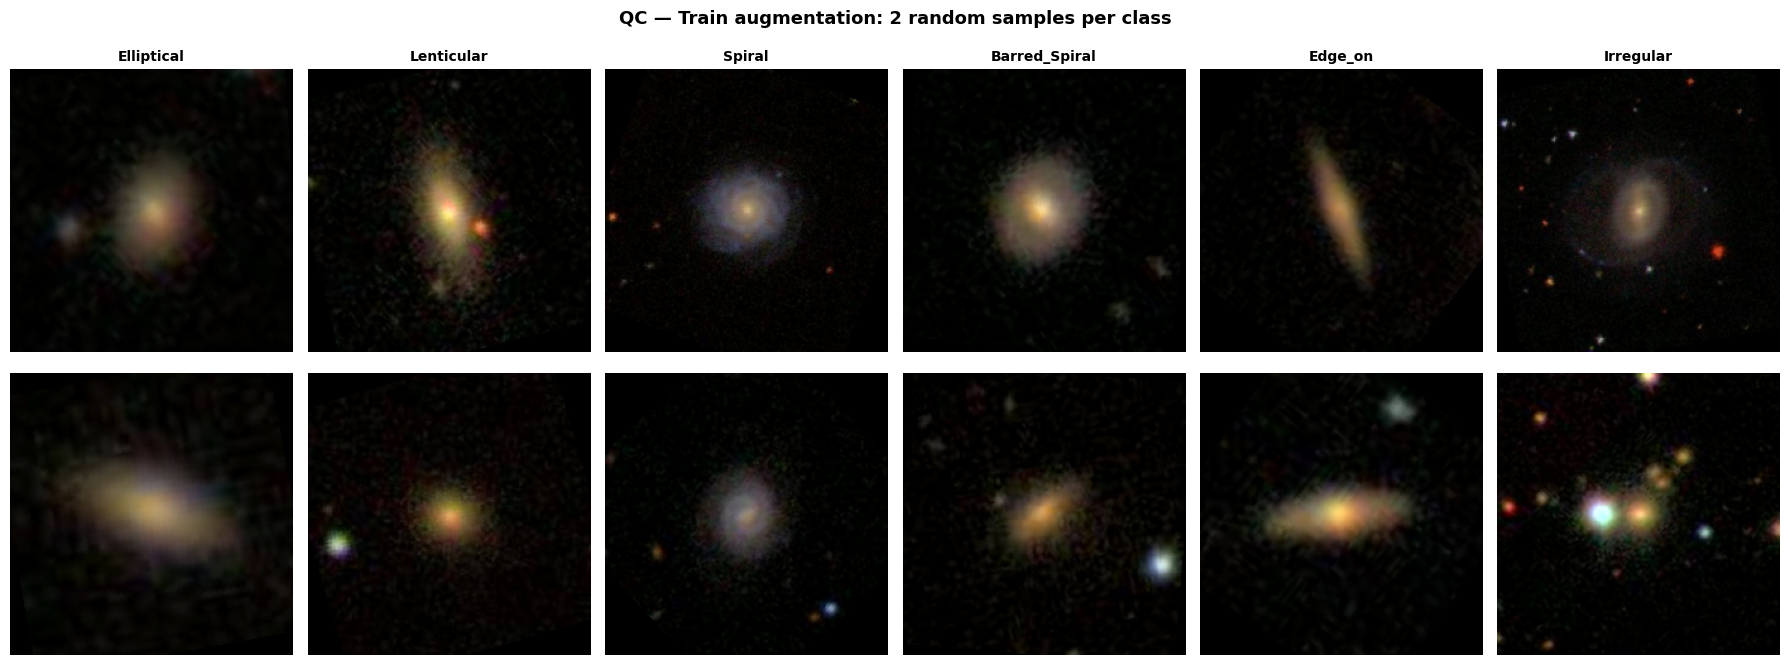

In [7]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for visualization."""
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


# Sample one image per class from the train dataset (with augmentation applied)
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
train_df = train_dataset.df.reset_index(drop=True)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle(
    "QC — Train augmentation: 2 random samples per class",
    fontsize=13, fontweight="bold"
)

for col, cls in enumerate(CLASS_ORDER):
    cls_indices = train_df[train_df["morph_label"] == cls].index.tolist()
    chosen = np.random.default_rng(RANDOM_SEED + col).choice(cls_indices, size=2, replace=False)
    for row, idx in enumerate(chosen):
        img_tensor, label = train_dataset[int(idx)]
        img_np = denormalize(img_tensor).permute(1, 2, 0).numpy()
        axes[row, col].imshow(img_np)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(cls, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

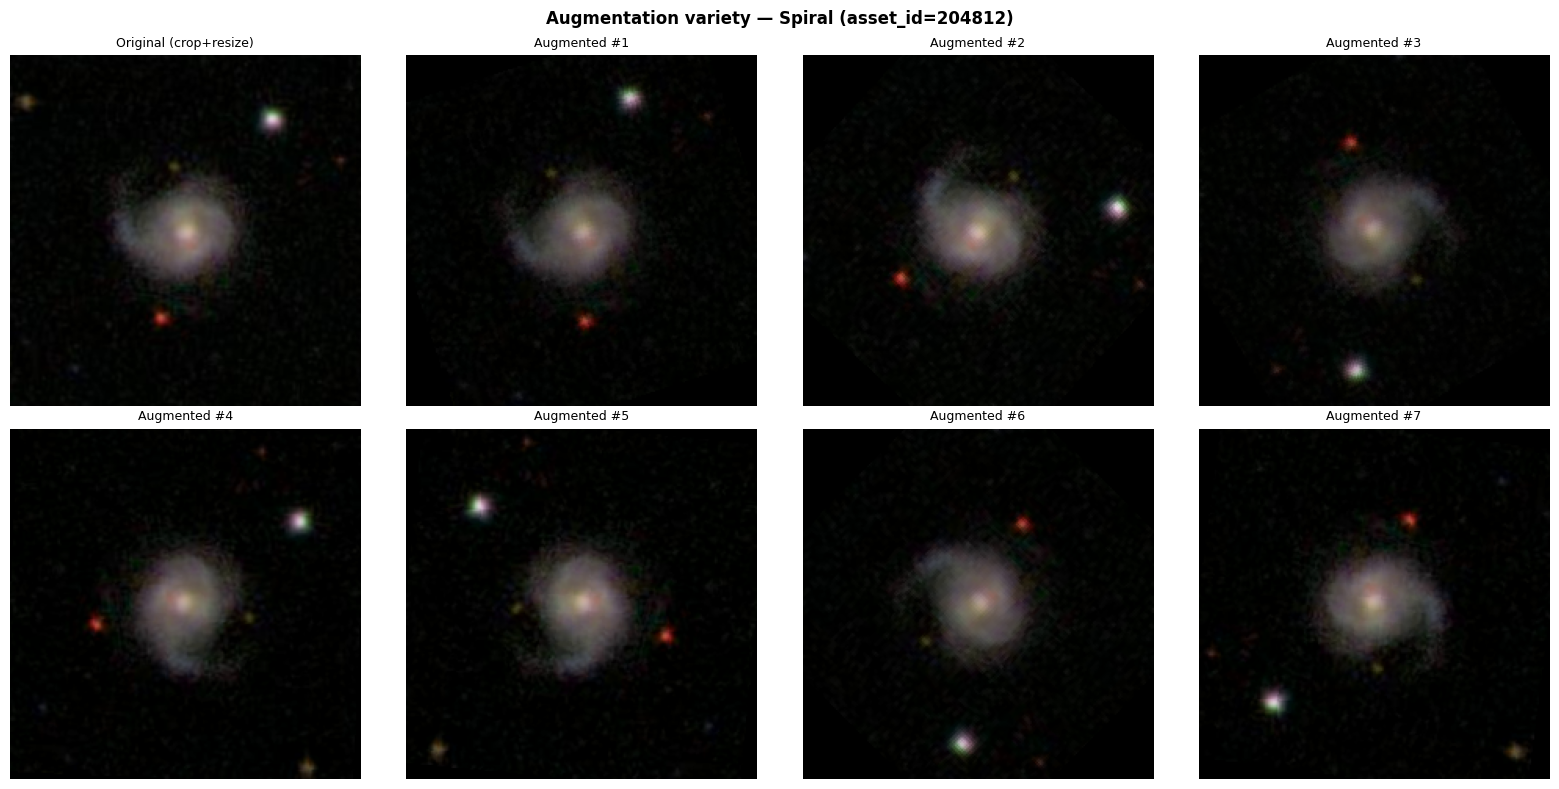

In [8]:
# Show the same image 6 times with different random augmentations
# to verify that rotations and flips look correct
sample_idx = train_df[train_df["morph_label"] == "Spiral"].index[0]
sample_row = train_df.iloc[sample_idx]
raw_img = Image.open(IMAGES_DIR / sample_row["img_filename"]).convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    f"Augmentation variety — {sample_row['morph_label']} (asset_id={sample_row['asset_id']})",
    fontsize=12, fontweight="bold"
)

# First image: original (only CenterCrop + Resize, no augment)
base = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),
    transforms.Resize(IMAGE_SIZE),
])
axes[0, 0].imshow(base(raw_img))
axes[0, 0].set_title("Original (crop+resize)", fontsize=9)
axes[0, 0].axis("off")

# Rest: augmented versions
for i, ax in enumerate(axes.flat[1:]):
    t = train_transforms(raw_img)
    img_np = denormalize(t).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f"Augmented #{i+1}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Sección 6 — Class weights

Calculamos los pesos de clase para usar en `nn.CrossEntropyLoss(weight=class_weights)`.
La fórmula es la de sklearn `'balanced'`: $w_c = \frac{N}{K \cdot n_c}$
donde $N$ = total de muestras, $K$ = número de clases, $n_c$ = muestras de la clase $c$.

In [9]:
train_labels = train_dataset.df["morph_label"].map(CLASS_TO_IDX).values
label_counts = np.bincount(train_labels, minlength=len(CLASS_ORDER))

N = len(train_labels)
K = len(CLASS_ORDER)
weights = N / (K * label_counts)

class_weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights for CrossEntropyLoss:")
print("-" * 40)
for cls, w, n in zip(CLASS_ORDER, weights, label_counts):
    print(f"  {cls:<15}  n={n:>6,}   w={w:.4f}")
print("-" * 40)
print(f"  {'Ratio max/min':<15}  {weights.max()/weights.min():.2f}×")
print(f"\nclass_weights tensor: {class_weights}")

Class weights for CrossEntropyLoss:
----------------------------------------
  Elliptical       n=17,500   w=0.7408
  Lenticular       n=11,848   w=1.0943
  Spiral           n=17,500   w=0.7408
  Barred_Spiral    n=17,500   w=0.7408
  Edge_on          n= 9,292   w=1.3953
  Irregular        n= 4,149   w=3.1248
----------------------------------------
  Ratio max/min    4.22×

class_weights tensor: tensor([0.7408, 1.0943, 0.7408, 0.7408, 1.3953, 3.1248])


## Sección 7 — Verificación de un batch

In [13]:
# Fetch one batch and verify shapes and value ranges
images_batch, labels_batch = next(iter(train_loader))

print("Batch verification")
print("-" * 40)
print(f"  images shape  : {tuple(images_batch.shape)}  (B × C × H × W)")
print(f"  labels shape  : {tuple(labels_batch.shape)}")
print(f"  dtype images  : {images_batch.dtype}")
print(f"  dtype labels  : {labels_batch.dtype}")
print(f"  pixel min/max : {images_batch.min():.3f} / {images_batch.max():.3f}")
print(f"  pixel mean    : {images_batch.mean():.3f}")
print(f"  unique labels : {sorted(labels_batch.unique().tolist())}")
print("-" * 40)
print("Batch OK ✓")

Batch verification
----------------------------------------
  images shape  : (32, 3, 224, 224)  (B × C × H × W)
  labels shape  : (32,)
  dtype images  : torch.float32
  dtype labels  : torch.int64
  pixel min/max : -2.118 / 2.640
  pixel mean    : -1.771
  unique labels : [0, 1, 2, 3, 4, 5]
----------------------------------------
Batch OK ✓


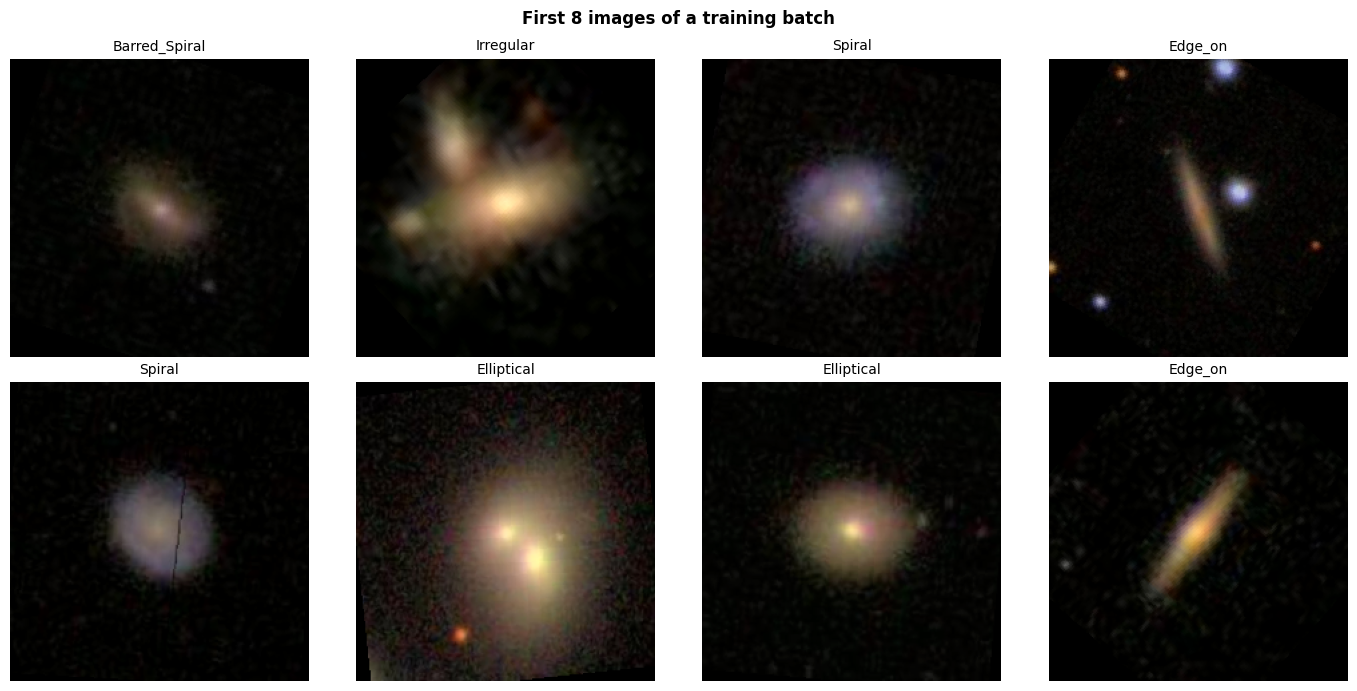

In [14]:
# Visual check of the first 8 images in the batch
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("First 8 images of a training batch", fontsize=12, fontweight="bold")

for ax, img_t, lbl in zip(axes.flat, images_batch[:8], labels_batch[:8]):
    img_np = denormalize(img_t).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(IDX_TO_CLASS[lbl.item()], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Sección 8 — Resumen

| Artefacto | Valor |
|-----------|-------|
| `train_loader` | 77,789 imgs · batch=32 · shuffle · augmentation |
| `val_loader` | 16,670 imgs · batch=32 · determinístico |
| `test_loader` | 16,670 imgs · batch=32 · determinístico |
| `class_weights` | tensor float32 shape=(6,) para `CrossEntropyLoss` |
| Input size | 3 × 224 × 224 (crop desde 320×320) |
| Normalización | ImageNet mean/std |

**Siguiente paso → `04_model_training.ipynb`**